# IT2011 AIML – Group Preprocessing Pipeline

Integrated preprocessing notebook for the Fitness Classification project.

Combined contributions:
1. Missing values
2. Mixed `smokes` cleaning
3. Outlier handling
4. Categorical encoding
5. BMI feature engineering
6. Standardization / scaling

**Your part: Member 6 – Standardization / Scaling**


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load Raw Dataset

Expected location:

`data/raw/fitness_dataset.csv`


In [2]:
candidate_paths = [
    Path("data/raw/fitness_dataset.csv"),
    Path("../data/raw/fitness_dataset.csv"),
    Path("fitness_dataset.csv")
]

data_path = None

for p in candidate_paths:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError(
        "fitness_dataset.csv was not found. "
        "Place it in data/raw/fitness_dataset.csv"
    )

df = pd.read_csv(data_path)

print("Loaded:", data_path)
print("Shape:", df.shape)
display(df.head())


Loaded: fitness_dataset.csv
Shape: (2000, 11)


,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,NaN,2.37,3.97,no,F,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,F,1
2,46,192,103,61.4,116.4,NaN,8.20,2.03,0,F,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,yes,F,1


## 3. Initial Inspection

In [3]:
print("Columns:", df.columns.tolist())
print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing_Count"))
print("\nDuplicates:", df.duplicated().sum())
print("\nTarget distribution:")
display(df["is_fit"].value_counts().sort_index().to_frame("Count"))


Columns: ['age', 'height_cm', 'weight_kg', 'heart_rate', 'blood_pressure', 'sleep_hours', 'nutrition_quality', 'activity_index', 'smokes', 'gender', 'is_fit']

Missing values:


,Missing_Count
age,0
height_cm,0
weight_kg,0
heart_rate,0
blood_pressure,0
sleep_hours,160
nutrition_quality,0
activity_index,0
smokes,0
gender,0



Duplicates: 0

Target distribution:


,Count
is_fit,
0,1201
1,799


# Member 1 – Missing Values

Handle missing `sleep_hours` using median imputation.


In [4]:
sleep_median = df["sleep_hours"].median()

print("Missing before:", df["sleep_hours"].isna().sum())
print("Median:", sleep_median)

df["sleep_hours"] = df["sleep_hours"].fillna(sleep_median)

print("Missing after:", df["sleep_hours"].isna().sum())


Missing before: 160
Median: 7.5
Missing after: 0


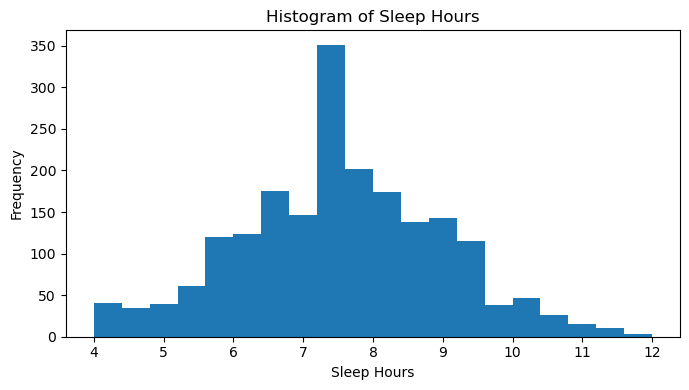

In [5]:
results_dir = Path("results/eda_visualizations")
results_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(7,4))
plt.hist(df["sleep_hours"], bins=20)
plt.title("Histogram of Sleep Hours")
plt.xlabel("Sleep Hours")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(results_dir / "sleep_hours_histogram.png", dpi=300)
plt.show()


# Member 2 – Mixed `smokes` Data Cleaning

Convert:
- yes → 1
- no → 0
- 1 → 1
- 0 → 0


In [6]:
print("Before:")
display(df["smokes"].value_counts(dropna=False).to_frame("Count"))

df["smokes"] = (
    df["smokes"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({"yes": "1", "no": "0"})
)

df["smokes"] = pd.to_numeric(df["smokes"], errors="coerce")

print("After:")
display(df["smokes"].value_counts(dropna=False).to_frame("Count"))


Before:


,Count
smokes,
yes,711
0,581
no,518
1,190


After:


,Count
smokes,
0,1099
1,901


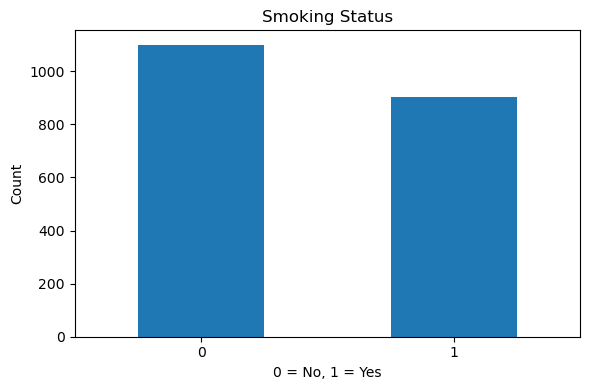

In [7]:
plt.figure(figsize=(6,4))
df["smokes"].value_counts().sort_index().plot(kind="bar")
plt.title("Smoking Status")
plt.xlabel("0 = No, 1 = Yes")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(results_dir / "smoking_status_bar_chart.png", dpi=300)
plt.show()


# Member 3 – Outlier Handling

Handle `weight_kg` outliers using the IQR method and cap extreme values.


In [8]:
Q1 = df["weight_kg"].quantile(0.25)
Q3 = df["weight_kg"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outlier_count = (
    (df["weight_kg"] < lower_limit) |
    (df["weight_kg"] > upper_limit)
).sum()

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower:", lower_limit)
print("Upper:", upper_limit)
print("Outliers:", outlier_count)

df["weight_kg"] = df["weight_kg"].clip(
    lower=lower_limit,
    upper=upper_limit
)


Q1: 64.0
Q3: 102.0
IQR: 38.0
Lower: 7.0
Upper: 159.0
Outliers: 21


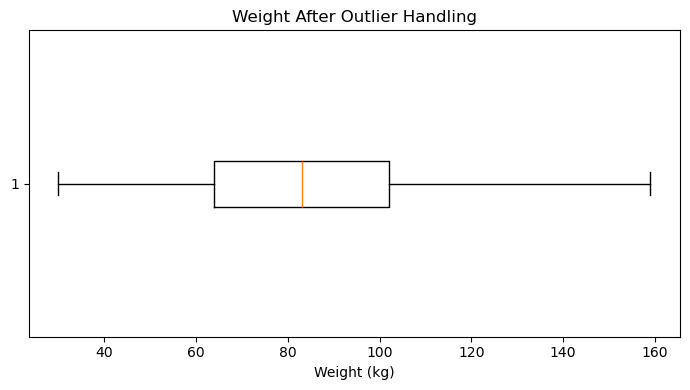

In [9]:
plt.figure(figsize=(7,4))
plt.boxplot(df["weight_kg"], vert=False)
plt.title("Weight After Outlier Handling")
plt.xlabel("Weight (kg)")
plt.tight_layout()
plt.savefig(results_dir / "weight_boxplot.png", dpi=300)
plt.show()


# Member 4 – Categorical Encoding

Encode gender:
- F → 0
- M → 1


In [10]:
print("Before:")
display(df["gender"].value_counts(dropna=False).to_frame("Count"))

df["gender"] = (
    df["gender"]
    .astype(str)
    .str.strip()
    .str.upper()
    .map({"F": 0, "M": 1})
)

print("After:")
display(df["gender"].value_counts(dropna=False).to_frame("Count"))


Before:


,Count
gender,
F,1030
M,970


After:


,Count
gender,
0,1030
1,970


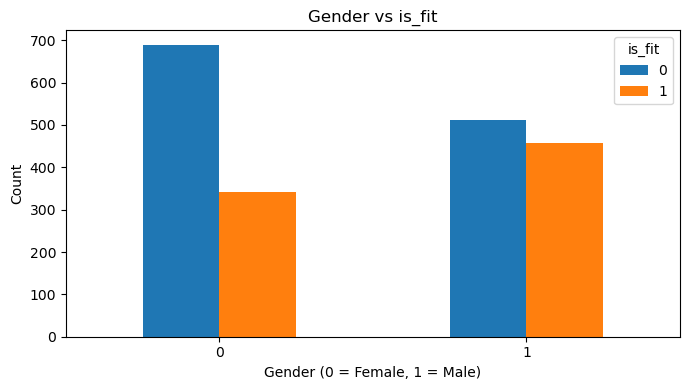

In [11]:
pd.crosstab(df["gender"], df["is_fit"]).plot(
    kind="bar",
    figsize=(7,4)
)
plt.title("Gender vs is_fit")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(results_dir / "gender_vs_is_fit.png", dpi=300)
plt.show()


# Member 5 – Feature Engineering (BMI)

Formula:

`BMI = weight_kg / (height_m)^2`


In [12]:
df["bmi"] = (
    df["weight_kg"] /
    ((df["height_cm"] / 100) ** 2)
)

display(df[["height_cm", "weight_kg", "bmi", "is_fit"]].head())


,height_cm,weight_kg,bmi,is_fit
0,152,65,28.133657,1
1,186,95,27.459822,1
2,192,103,27.940538,0
3,189,83,23.235632,1
4,175,99,32.326531,1


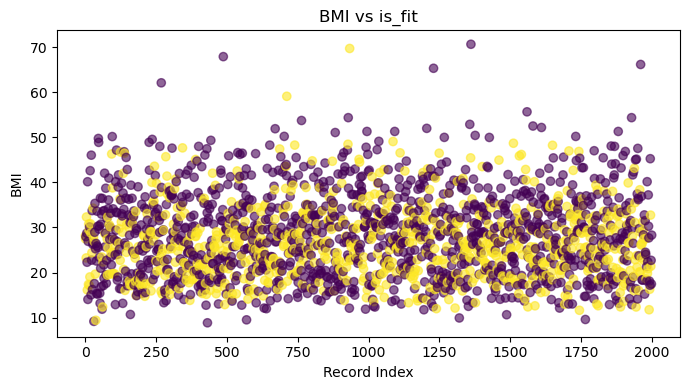

In [13]:
plt.figure(figsize=(7,4))
plt.scatter(df.index, df["bmi"], c=df["is_fit"], alpha=0.6)
plt.title("BMI vs is_fit")
plt.xlabel("Record Index")
plt.ylabel("BMI")
plt.tight_layout()
plt.savefig(results_dir / "bmi_vs_is_fit.png", dpi=300)
plt.show()


# Member 6 – Standardization / Scaling

## Your Part

Use `StandardScaler`.

Formula:

`z = (x - mean) / standard deviation`

After scaling:
- mean ≈ 0
- standard deviation ≈ 1

The target `is_fit` is not scaled.


In [14]:
X = df.drop(columns=["is_fit"])
y = df["is_fit"].copy()

numeric_features = X.select_dtypes(include=np.number).columns.tolist()

print("Features to scale:")
print(numeric_features)

scaler = StandardScaler()

X_scaled = X.copy()
X_scaled[numeric_features] = scaler.fit_transform(
    X[numeric_features]
)

display(X_scaled.head())


Features to scale:
['age', 'height_cm', 'weight_kg', 'heart_rate', 'blood_pressure', 'sleep_hours', 'nutrition_quality', 'activity_index', 'smokes', 'gender', 'bmi']


,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,bmi
0,0.384219,-1.568260,-0.776923,-0.058142,-0.199586,-0.008505,-0.930748,0.854644,-0.905448,-0.970437,0.040802
1,1.109581,0.798084,0.524455,-0.801174,-0.350536,-0.008505,1.304326,0.168084,-0.905448,-0.970437,-0.033473
2,-0.173752,1.215674,0.871490,-0.750512,-0.240755,-0.008505,1.105265,-0.852954,-0.905448,-0.970437,0.019515
3,-0.954911,1.006879,0.003904,-0.851835,0.699251,-0.355652,0.399820,0.599384,-0.905448,1.030464,-0.499092
4,0.607407,0.032502,0.697973,-1.029149,-0.281923,0.338642,1.716418,1.611620,1.104426,-0.970437,0.502970


In [15]:
scaling_check = pd.DataFrame({
    "Mean_After_Scaling": X_scaled[numeric_features].mean().round(4),
    "Std_After_Scaling": X_scaled[numeric_features].std(ddof=0).round(4)
})

display(scaling_check)


,Mean_After_Scaling,Std_After_Scaling
age,0.0,1.0
height_cm,0.0,1.0
weight_kg,0.0,1.0
heart_rate,0.0,1.0
blood_pressure,-0.0,1.0
sleep_hours,0.0,1.0
nutrition_quality,-0.0,1.0
activity_index,0.0,1.0
smokes,-0.0,1.0
gender,0.0,1.0


### Member 6 Visualization – Correlation Heatmap

Interpretation:
- close to +1 = strong positive correlation
- close to -1 = strong negative correlation
- close to 0 = weak linear relationship


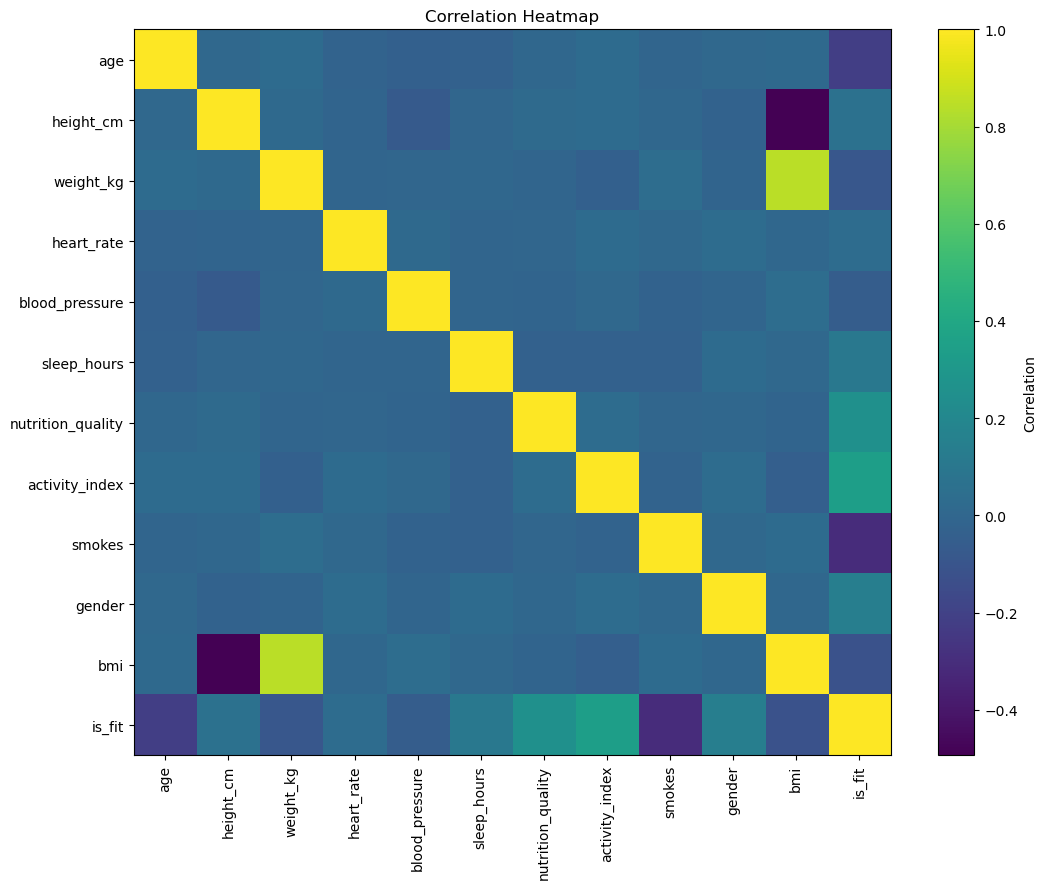

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,bmi,is_fit
age,1.000,0.011,0.031,-0.019,-0.037,-0.032,0.006,0.026,-0.006,0.009,0.016,-0.214
height_cm,0.011,1.000,0.016,-0.014,-0.069,-0.001,0.024,0.028,0.003,-0.025,-0.494,0.065
weight_kg,0.031,0.016,1.000,-0.004,-0.003,0.005,-0.004,-0.034,0.039,-0.012,0.848,-0.090
heart_rate,-0.019,-0.014,-0.004,1.000,0.019,-0.005,0.001,0.029,0.010,0.034,0.005,0.033
blood_pressure,-0.037,-0.069,-0.003,0.019,1.000,-0.008,-0.014,0.011,-0.024,-0.006,0.038,-0.051
sleep_hours,-0.032,-0.001,0.005,-0.005,-0.008,1.000,-0.030,-0.031,-0.027,0.031,0.011,0.105
nutrition_quality,0.006,0.024,-0.004,0.001,-0.014,-0.030,1.000,0.033,0.002,0.008,-0.013,0.255
activity_index,0.026,0.028,-0.034,0.029,0.011,-0.031,0.033,1.000,-0.019,0.032,-0.040,0.343
smokes,-0.006,0.003,0.039,0.010,-0.024,-0.027,0.002,-0.019,1.000,0.012,0.031,-0.302
gender,0.009,-0.025,-0.012,0.034,-0.006,0.031,0.008,0.032,0.012,1.000,0.003,0.144


In [16]:
scaled_df = X_scaled.copy()
scaled_df["is_fit"] = y.values

corr = scaled_df.corr(numeric_only=True)

plt.figure(figsize=(11,9))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(results_dir / "correlation_heatmap.png", dpi=300)
plt.show()

display(corr.round(3))


# 10. Save Final Processed Dataset

Output:

`results/outputs/fitness_processed.csv`


In [17]:
final_df = X_scaled.copy()
final_df["is_fit"] = y.values

output_dir = Path("results/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "fitness_processed.csv"

final_df.to_csv(output_path, index=False)

print("Saved:", output_path)
print("Final shape:", final_df.shape)
print("Total missing values:", final_df.isna().sum().sum())

display(final_df.head())


Saved: results\outputs\fitness_processed.csv
Final shape: (2000, 12)
Total missing values: 0


,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,bmi,is_fit
0,0.384219,-1.568260,-0.776923,-0.058142,-0.199586,-0.008505,-0.930748,0.854644,-0.905448,-0.970437,0.040802,1
1,1.109581,0.798084,0.524455,-0.801174,-0.350536,-0.008505,1.304326,0.168084,-0.905448,-0.970437,-0.033473,1
2,-0.173752,1.215674,0.871490,-0.750512,-0.240755,-0.008505,1.105265,-0.852954,-0.905448,-0.970437,0.019515,0
3,-0.954911,1.006879,0.003904,-0.851835,0.699251,-0.355652,0.399820,0.599384,-0.905448,1.030464,-0.499092,1
4,0.607407,0.032502,0.697973,-1.029149,-0.281923,0.338642,1.716418,1.611620,1.104426,-0.970437,0.502970,1


# Viva Summary – Member 6

**Technique:** Standardization / Scaling  
**Library:** `sklearn.preprocessing.StandardScaler`  
**Reason:** Input features have different numerical ranges.  
**Formula:** `z = (x - mean) / standard deviation`  
**Expected result:** Mean approximately 0 and standard deviation approximately 1.  
**Target:** `is_fit` is not scaled.  
**Scale-sensitive models:** Logistic Regression, KNN, SVM.
